In [ ]:
pip install opencv-python

In [ ]:
pip install tensorflow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
source_path = "/content/drive/My Drive/FER-2013/train"
test_path = "/content/drive/My Drive/FER-2013/train"


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


import os
import cv2
import tensorflow as tf
from PIL import Image




In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, GlobalAvgPool2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy

In [ ]:
data = []


for emotion in os.listdir(source_path):

    file_path = os.path.join(source_path, emotion)

    for image in os.listdir(file_path):

        image_path = os.path.join(file_path, image)

        with Image.open(image_path) as img:

            img_array = np.array(img)
            data.append({"Image": img_array, 'Emotion': emotion})










In [ ]:



for emotion in os.listdir(test_path):

    file_path = os.path.join(test_path, emotion)

    for image in os.listdir(file_path):

        image_path = os.path.join(file_path, image)

        with Image.open(image_path) as img:

            img_array = np.array(img)
            data.append({"Image": img_array, 'Emotion': emotion })

In [ ]:
df = pd.DataFrame(data)

In [ ]:
df

,Image,Emotion
0,"[[60, 127, 154, 162, 168, 176, 189, 193, 203, ...",fear
1,"[[23, 30, 31, 15, 22, 1, 5, 35, 56, 67, 94, 10...",fear
2,"[[140, 86, 64, 47, 50, 69, 74, 89, 123, 134, 1...",fear
3,"[[248, 227, 212, 196, 196, 180, 194, 180, 188,...",fear
4,"[[77, 81, 35, 49, 111, 86, 79, 87, 79, 86, 89,...",fear
...,...,...
57423,"[[209, 213, 210, 207, 82, 33, 37, 25, 29, 37, ...",sad
57424,"[[206, 207, 213, 173, 54, 23, 22, 22, 16, 20, ...",sad
57425,"[[250, 241, 232, 225, 219, 212, 208, 206, 207,...",sad
57426,"[[26, 24, 25, 25, 25, 25, 27, 27, 31, 47, 65, ...",sad


In [ ]:
model = Sequential([

    Conv2D(filters = 128, kernel_size= (3,3), activation= 'relu', input_shape = (48,48,1)),
    MaxPooling2D(pool_size=(2,2)),
    BatchNormalization(),



    Conv2D(filters = 256, kernel_size = (3,3), activation = 'relu'),

    BatchNormalization(),
    Conv2D(filters = 512, kernel_size = (3,3), activation = 'relu'),


    Conv2D(filters = 512, kernel_size = (3,3), activation = 'relu'),
    MaxPooling2D(pool_size=(2,2)),
    BatchNormalization(),
    Conv2D(filters = 512, kernel_size = (3,3), activation = 'relu'),
    MaxPooling2D(pool_size=(2,2)),
    BatchNormalization(),

    GlobalAvgPool2D(),

    Dense(512, activation = 'relu'),
    Dense(256, activation = 'relu'),


    Dense(7, activation= "softmax")



])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer = Adam(), loss  = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df["Image"]
y  = df["Emotion"]

In [ ]:
X = list(X)

In [ ]:
y = list(y)

In [ ]:
X = np.array(X)
y = np.array(y)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le  = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
X

array([[[ 60, 127, 154, ...,   9,   4,   5],
        [101, 149, 162, ...,  12,   8,   9],
        [118, 153, 165, ...,  16,   7,   3],
        ...,
        [ 12,  10,  17, ..., 183, 181, 178],
        [ 13,  11,  14, ..., 174, 178, 173],
        [ 11,  14,  15, ..., 171, 166, 154]],

       [[ 23,  30,  31, ..., 244, 245, 244],
        [ 17,  26,  19, ..., 245, 244, 245],
        [ 27,  16,   1, ..., 243, 244, 244],
        ...,
        [ 90,  91,  77, ..., 132, 149, 163],
        [ 87,  86,  90, ..., 126, 133, 150],
        [ 78,  70,  71, ..., 108, 131, 143]],

       [[140,  86,  64, ..., 215, 215, 215],
        [178, 116,  67, ..., 216, 216, 211],
        [158,  85,  58, ..., 216, 214, 214],
        ...,
        [ 21,  22,  21, ...,  25,  16,  18],
        [ 19,  23,  19, ...,  16,  17,  17],
        [ 22,  19,  20, ...,  15,  16,  14]],

       ...,

       [[250, 241, 232, ..., 238, 242, 238],
        [239, 229, 214, ..., 234, 230, 234],
        [234, 212, 186, ..., 225, 228, 229

In [ ]:
X_train, X_test,y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state= 42)

In [ ]:
model.fit(X_train, y_train, epochs = 20, validation_data=(X_test, y_test), batch_size= 32 )

Epoch 1/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 99s 69ms/step - accuracy: 0.3133 - loss: 1.7219 - val_accuracy: 0.3811 - val_loss: 1.5812
Epoch 2/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.5147 - loss: 1.2732 - val_accuracy: 0.4983 - val_loss: 1.3120
Epoch 3/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.5961 - loss: 1.0735 - val_accuracy: 0.5694 - val_loss: 1.1313
Epoch 4/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.6643 - loss: 0.8941 - val_accuracy: 0.6050 - val_loss: 1.0691
Epoch 5/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.7408 - loss: 0.7041 - val_accuracy: 0.6491 - val_loss: 0.9909
Epoch 6/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 78s 61ms/step - accuracy: 0.8154 - loss: 0.5092 - val_accuracy: 0.7083 - val_loss: 0.8903
Epoch 7/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - accuracy: 0.8792 - loss: 0.3423 - val_accuracy: 0.7707 - val_loss: 0.7765
Epoch 8/20
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 86s 64ms/step - accuracy: 0.9179 -

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import  matplotlib.pyplot as plt

In [ ]:
y_pred = model.predict(X_test)

539/539 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step


In [ ]:
y_pred_classes = np.argmax(y_pred, axis = 1)


In [ ]:
y_pred_actual = le.inverse_transform(y_pred_classes)
y_test_actual = le.inverse_transform(y_test)

In [ ]:
y_pred_actual

array(['happy', 'neutral', 'angry', ..., 'happy', 'sad', 'neutral'],
      dtype='<U8')

In [ ]:
y_test_actual

array(['happy', 'happy', 'sad', ..., 'happy', 'neutral', 'neutral'],
      dtype='<U8')

In [ ]:
cm = confusion_matrix(y_test_actual, y_pred_actual)

In [ ]:
emotion_labels = le.classes_

Text(95.72222222222221, 0.5, 'Actual')

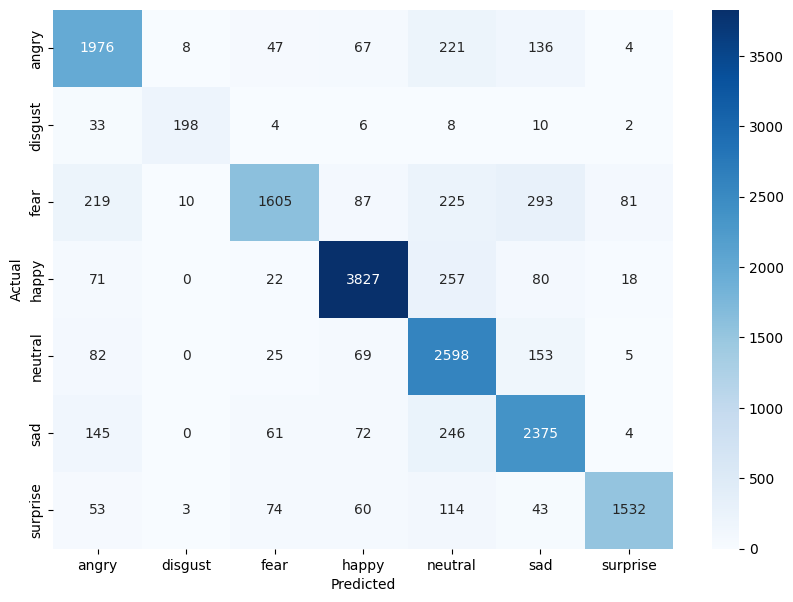

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [ ]:
model_json = model.to_json()
with open("/content/drive/MyDrive/FER-2013/emotiondetector.json",'w') as json_file:
    json_file.write(model_json)
model.save("/content/drive/MyDrive/FER-2013/emotiondetector.h5")